In [1]:
import numpy as np
from pylab import gca
import numpy as np
import math
from tqdm import tqdm
import torch
import torchvision
import torch.nn as nn
from torch.utils import data
import torch.nn.functional as F
from torchvision import transforms
from torchvision.utils import save_image
from torchvision.datasets import MNIST
import torchvision.transforms.functional as TF
from torch.optim import lr_scheduler
import time
import os
import cv2
import os
from torchvision import transforms
from torch.utils.data import DataLoader
from pathlib import Path
from torch.utils.data import Dataset
import pdb
from PIL import Image
import matplotlib.pyplot as plt 
from runners.train_diffusion import forwardpass
from analysis_functions import predict_lrenc, predict_mobilenet, predict_diffusion, plot_images, get_profile, load_mobilenet, load_encoder, load_diffusion, PSNR, SSIM

In [2]:
def frame_tick(frame_width = 2, tick_width = 1.5):
    ax = gca()
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(frame_width)
    plt.tick_params(direction = 'in', 
                    width = tick_width)
def legend(location = 'best', fontsize = 8):
        plt.legend(loc = location, fontsize = fontsize, frameon = False)

### Define results directory

In [3]:
diffusion_results_dir = '/home/oogoke/DiffusionSR/runs/clean/direct/diffusion/2022_12_12_02_33_57/standardize/n_steps_1'
encoder_results_dir = '/home/oogoke/DiffusionSR/runs/clean/direct/encoder/2022_12_04_11_32_01/standardize/'
mobilenet_results_dir = '/home/oogoke/DiffusionSR/runners/runs/clean/lanczos/mobilenet/2022_12_05_10_23_02'


### Plot Train, Test Loss for diffusion

In [2]:
import numpy as np
test_loss = np.loadtxt(os.path.join(diffusion_results_dir, 'test_loss_epoch.txt'))
train_loss = np.loadtxt(os.path.join(diffusion_results_dir, 'loss_epoch.txt'))

plt.figure(figsize = np.array([4,3])*1.25, dpi = 150)

plt.plot(train_loss[:], label = 'Training Loss')
plt.plot(np.mean(test_loss[:24*70].reshape(-1, 24), axis=1), label = "Validation Loss")

plt.xlabel(r'Epoch ($3000$ iterations)')
plt.ylabel(r'$L_1$ Loss')
legend()

plt.title('Diffusion Model Loss')
plt.grid(which = 'major')
frame_tick()

NameError: name 'diffusion_results_dir' is not defined

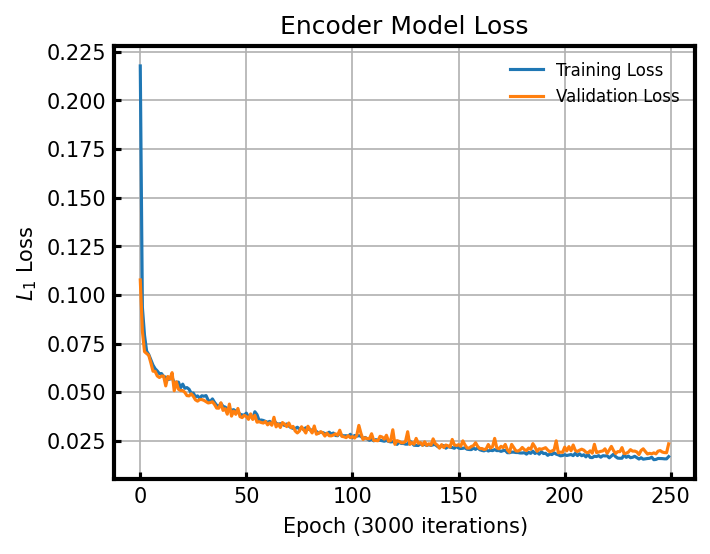

In [37]:
import numpy as np
test_loss = np.loadtxt(os.path.join(encoder_results_dir, 'test_loss.txt'))
train_loss = np.loadtxt(os.path.join(encoder_results_dir, 'train_loss.txt'))

plt.figure(figsize = np.array([4,3])*1.25, dpi = 150)

plt.plot(train_loss[:], label = 'Training Loss')
plt.plot(test_loss, label = "Validation Loss")

plt.xlabel(r'Epoch ($3000$ iterations)')
plt.ylabel(r'$L_1$ Loss')
legend()

plt.title('Encoder Model Loss')
plt.grid(which = 'major')
frame_tick()

In [ ]:
import numpy as np
test_loss = np.loadtxt(os.path.join(mobilenet_results_dir, 'test_loss.txt'))
train_loss = np.loadtxt(os.path.join(mobilenet_results_dir, 'train_loss.txt'))

plt.figure(figsize = np.array([4,3])*1.25, dpi = 150)

plt.plot(train_loss[:], label = 'Training Loss')
plt.plot(test_loss, label = "Validation Loss")

plt.xlabel(r'Epoch ($3000$ iterations)')
plt.ylabel(r'$L_1$ Loss')
legend()

plt.title('Encoder Model Loss')
plt.grid(which = 'major')
frame_tick()

In [5]:
image_size = 80
channels = 1
batch_size = 4
from datasets.dataset import TemperatureXZDataset
train_dataset = TemperatureXZDataset(method = 'direct', split = 'train', root_folder = '/home/oogoke/DiffusionSR/datasets/update_v2_laser_velocity_xz_cross_section_data')
test_dataset = TemperatureXZDataset(method ='lanczos', split = 'test', root_folder = '/home/oogoke/DiffusionSR/datasets/update_v2_laser_velocity_xz_cross_section_data')
dev_dataset = TemperatureXZDataset(method = 'lanczos', split = 'dev', root_folder = '/home/oogoke/DiffusionSR/datasets/update_v2_laser_velocity_xz_cross_section_data')

dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
dev_dataloader = DataLoader(dev_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

len data: 3044
len data: 609
len data: 406


In [7]:
from models.diffusion_model import Unet
from models.lr_encoder_model import rrdbnet_encoder as rrdbnet_x4
os.environ['CUDA_VISIBLE_DEVICES']  = "2"
device = 'cuda'
criterion = torch.nn.L1Loss()
lr_enc = load_encoder(encoder_results_dir)
mobilenet = load_mobilenet(mobilenet_results_dir)
model = load_diffusion(diffusion_results_dir)

batch_size = 1
dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
# res, hr, lr, upscaled_lr =  iter(dataloader).next()
# input, result, target = predict_lrenc(lr_enc,res, hr, lr, upscaled_lr, train_dataset)


### Plot test set melt pools

In [12]:
for batch_idx, (res, hr, lr, upscaled_lr) in enumerate(dev_dataloader):  
    input, lr_enc_result, target = predict_lrenc(lr_enc,res, hr, lr, upscaled_lr, dev_dataset)
    print(input.shape)
    input, result_diffusion, target = predict_diffusion(model, lr_enc, res, hr, lr, upscaled_lr,dev_dataset)
    input, result_mobilenet, target = predict_mobilenet(mobilenet,res, hr, lr, upscaled_lr, dev_dataset)

    plot_images(input[0], lr_enc_result[0,0], target[0][0], split = 'Test', modeltype = "Encoder")
    plot_images(input[0], result_mobilenet[0,0], target[0][0], split = 'Test', modeltype = "MobileNetSISR")
    plot_images(input[0], result_diffusion[0], target[0][0], split = 'Test', modeltype = "Diffusion")
    


torch.Size([4, 20, 20])
200 [1] 4
torch.Size([4, 64, 80, 80])


sampling loop time step:   0%|          | 0/200 [00:00<?, ?it/s]

KeyboardInterrupt: 

### Calculate melt pool and keyhole dimensions

In [13]:
max_depth_enc = []
max_depth_diff = []
max_depth_mbn = []

max_depth_gt = []
max_depth_input = []
kp_depth_enc = []
kp_depth_diff = []
kp_depth_mbn = []

kp_depth_gt = []
kp_depth_input = []
for batch_idx, (res, hr, lr, upscaled_lr) in enumerate(dev_dataloader):  
    input, lr_enc_result, target = predict_lrenc(lr_enc,res, hr, lr, upscaled_lr, dev_dataset)

    input, result_diffusion, target = predict_diffusion(model, lr_enc, res, hr, lr, upscaled_lr, dev_dataset)
    input, result_mobilenet, target = predict_mobilenet(mobilenet, res, hr, lr, upscaled_lr, dev_dataset)


    profile_enc, kp_enc = get_profile(lr_enc_result)
    profile_diff, kp_diff = get_profile(result_diffusion)
    profile_mbn, kp_mbn = get_profile(result_mobilenet)
    profile_gt, kp_gt = get_profile(target)
    profile_input, kp_input = get_profile(input, mesh = 20)
    max_depth_enc.append(5*(80-np.min(profile_enc)))
    max_depth_gt.append(5*(80-np.min(profile_gt)))
    max_depth_diff.append(5*(80-np.min(profile_diff)))
    max_depth_mbn.append(5*(80-np.min(profile_mbn)))

    max_depth_input.append(20*(20-np.min(profile_input)))
    kp_depth_enc.append(5*(80-np.min(kp_enc)))
    kp_depth_gt.append(5*(80-np.min(kp_gt)))
    kp_depth_input.append(20*(20-np.min(kp_input)))
    kp_depth_diff.append(5*(80-np.min(kp_diff)))
    kp_depth_mbn.append(5*(80-np.min(kp_mbn)))

200 [1] 4
torch.Size([4, 64, 80, 80])


sampling loop time step:   0%|          | 0/200 [00:00<?, ?it/s]

200 [1] 4
torch.Size([4, 64, 80, 80])


sampling loop time step:   0%|          | 0/200 [00:00<?, ?it/s]

200 [1] 4
torch.Size([4, 64, 80, 80])


...

200 [1] 4
torch.Size([4, 64, 80, 80])


sampling loop time step:   0%|          | 0/200 [00:00<?, ?it/s]

200 [1] 4
torch.Size([4, 64, 80, 80])


sampling loop time step:   0%|          | 0/200 [00:00<?, ?it/s]

KeyboardInterrupt: 

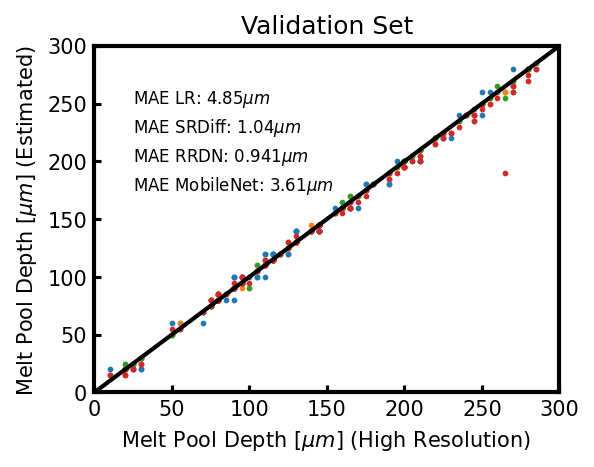

In [44]:
import sklearn
from sklearn.metrics import mean_absolute_error
plt.figure(figsize = [4,3], dpi = 150)
plt.plot(np.arange(300),np.arange(300), 'k-', linewidth = 2.0)
plt.scatter(max_depth_gt, max_depth_input, s = 3.0, label = 'Low Resolution')
plt.scatter(max_depth_gt, max_depth_diff, s = 3.0, label = 'Super Resolution')
plt.scatter(max_depth_gt, max_depth_enc, s = 3.0, label = 'Super Resolution')
plt.scatter(max_depth_gt, max_depth_mbn, s = 3.0, label = 'Super Resolution')

mae_input = mean_absolute_error(max_depth_gt, max_depth_input)
mae_depth_diff = mean_absolute_error(max_depth_gt, max_depth_diff)
mae_depth_enc = mean_absolute_error(max_depth_gt, max_depth_enc)
mae_depth_mbn = mean_absolute_error(max_depth_gt, max_depth_mbn)
plt.xlim(0,300)
plt.ylim(0,300)
frame_tick()
plt.xlabel(r'Melt Pool Depth [$\mu m]$ (High Resolution) ')
plt.ylabel(r'Melt Pool Depth [$\mu m]$ (Estimated) ')
plt.title('Validation Set')
plt.text(25, 250,r'MAE LR: {:.03}$\mu m$'.format(mae_input), fontsize = 8 )
plt.text(25, 225,r'MAE SRDiff: {:.03}$\mu m$'.format(mae_depth_diff), fontsize = 8 )
plt.text(25, 200,r'MAE RRDN: {:.03}$\mu m$'.format(mae_depth_enc), fontsize = 8 )
plt.text(25, 175,r'MAE MobileNet: {:.03}$\mu m$'.format(mae_depth_mbn), fontsize = 8 )
plt.show()

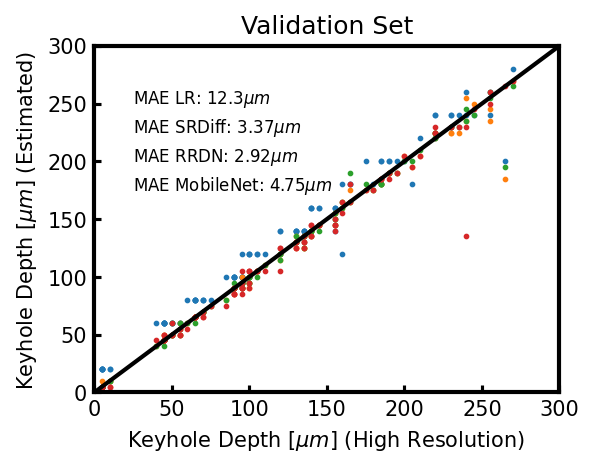

In [45]:
import sklearn
from sklearn.metrics import mean_absolute_error
plt.figure(figsize = [4,3], dpi = 150)
plt.plot(np.arange(300),np.arange(300), 'k-', linewidth = 2.0)
plt.scatter(kp_depth_gt, kp_depth_input, s = 3.0, label = 'Low Resolution')
plt.scatter(kp_depth_gt, kp_depth_diff, s = 3.0, label = 'Super Resolution')
plt.scatter(kp_depth_gt, kp_depth_enc, s = 3.0, label = 'Super Resolution')
plt.scatter(kp_depth_gt, kp_depth_mbn, s = 3.0, label = 'Super Resolution')


mae_input = mean_absolute_error(kp_depth_gt, kp_depth_input)
mae_depth_diff = mean_absolute_error(kp_depth_gt, kp_depth_diff)
mae_depth_enc = mean_absolute_error(kp_depth_gt, kp_depth_enc)
mae_depth_mbn = mean_absolute_error(kp_depth_gt, kp_depth_mbn)
plt.xlim(0,300)
plt.ylim(0,300)
frame_tick()
plt.xlabel(r'Keyhole Depth [$\mu m]$ (High Resolution) ')
plt.ylabel(r'Keyhole Depth [$\mu m]$ (Estimated) ')
plt.title('Validation Set')
plt.text(25, 250,r'MAE LR: {:.03}$\mu m$'.format(mae_input), fontsize = 8 )
plt.text(25, 225,r'MAE SRDiff: {:.03}$\mu m$'.format(mae_depth_diff), fontsize = 8 )
plt.text(25, 200,r'MAE RRDN: {:.03}$\mu m$'.format(mae_depth_enc), fontsize = 8 )
plt.text(25, 175,r'MAE MobileNet: {:.03}$\mu m$'.format(mae_depth_mbn), fontsize = 8 )   
plt.show()

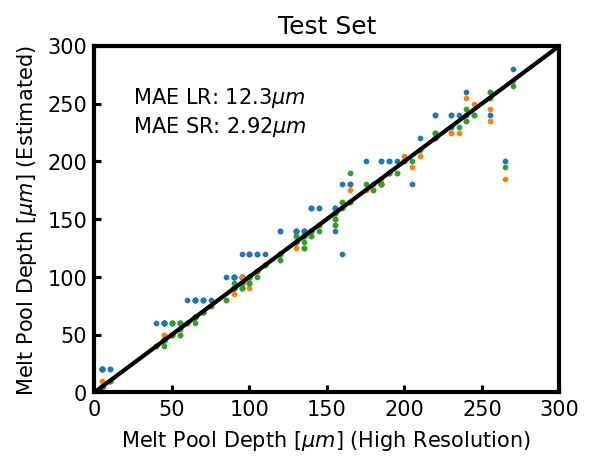

In [46]:
import sklearn
from sklearn.metrics import mean_absolute_error
plt.figure(figsize = [4,3], dpi = 150)
plt.plot(np.arange(300),np.arange(300), 'k-', linewidth = 2.0)
plt.scatter(kp_depth_gt, kp_depth_input, s = 3.0, label = 'Low Resolution')
plt.scatter(kp_depth_gt, kp_depth_diff, s = 3.0, label = 'Super Resolution')
plt.scatter(kp_depth_gt, kp_depth_enc, s = 3.0, label = 'Super Resolution')

mae_input = mean_absolute_error(kp_depth_gt, kp_depth_input)
mae_depth = mean_absolute_error(kp_depth_gt, kp_depth_enc)

plt.xlim(0,300)
plt.ylim(0,300)
frame_tick()
plt.xlabel(r'Melt Pool Depth [$\mu m]$ (High Resolution) ')
plt.ylabel(r'Melt Pool Depth [$\mu m]$ (Estimated) ')
plt.title('Test Set')
plt.text(25, 250,r'MAE LR: {:.03}$\mu m$'.format(mae_input) )
plt.text(25, 225,r'MAE SR: {:.03}$\mu m$'.format(mae_depth) )
plt.show()

In [ ]:
def plot_temp_lines(input, result, target, modeltype, split = 'train'):
    scaling_factor = 1.5
    dpi = 90
    min_temp = 293
    max_temp = 8000
    method = 'direct'
    plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)
    plt.title(r'{} model, Cross section: x = 200 $\mu m$'.format(modeltype))
    plt.plot(80*5*(np.arange(input.shape[-1])/input.shape[-1]),input[0][10,:],label = 'Low-Resolution Input')
    plt.plot(80*5*(np.arange(target.shape[-1])/target.shape[-1]),target[40,:], label = 'High-Resolution Input') 
    plt.plot(80*5*(np.arange(target.shape[-1])/target.shape[-1]),result[40,:], label = 'Output')
    legend()
    plt.ylabel(r'$T [K]$')
    plt.xlabel(r'$z [\mu m$]')
    frame_tick()
    plt.ylim(min_temp, max_temp)
    plt.xlim(0, 400)
    plt.show()
plot_temp_lines(input, result_diffusion[0], target[0][0], split = 'test', modeltype = "Diffusion")
plot_temp_lines(input, lr_enc_result[0][0], target[0][0], split = 'test', modeltype = "Encoder")


In [ ]:
def plot_srdiff_contours(input, result, target, modeltype, split = 'train', max_temp = 5000, min_temp = 293, dpi = 90, scaling_factor = 1.5, method = 'Direct'):
    profile_result, kp_result = get_profile(result)

    profile_gt, kp_gt = get_profile(target)
    profile_input, kp_input = get_profile(input, mesh = 20)

    plt.figure(dpi = 150, figsize = np.array([4,3])*1.25)
    plt.plot(20*np.arange(20), kp_input*20 - 400, '--', label = 'Low Resolution (Input)')
    plt.plot(5*np.arange(80), kp_result*5 - 400, label = 'Super Resolution (Output)' )
    plt.plot(5*np.arange(80), kp_gt*5 - 400, 'k', linewidth = 2.0, label = 'High Resolution')
    frame_tick()

    legend()
    plt.title('[{} Data] Keyhole Depth, {}'.format(split, modeltype), fontsize = 10)
    plt.xlabel(r'x [$\mu m$] ')
    plt.ylabel(r'z [$\mu m$] ')
    plt.show()

    plt.figure(dpi = 150, figsize = np.array([4,3])*1.25)
    plt.plot(20*np.arange(20),profile_input*20 - 400, '--', label = 'Low Resolution (Input)')
    plt.plot(5*np.arange(80), profile_result*5 - 400, label = 'Super Resolution (Output)' )
    plt.plot(5*np.arange(80),profile_gt*5 - 400, 'k', linewidth = 2.0, label = 'High Resolution')
    frame_tick()

    legend()
    plt.title('[{} Data] Melt Pool Depth, {}'.format(split, modeltype), fontsize = 10)
    plt.xlabel(r'x [$\mu m$] ')
    plt.ylabel(r'z [$\mu m$] ')
    plt.show()
input, lr_enc_result, target = predict_lrenc(lr_enc,res, hr, lr, upscaled_lr, train_dataset)
print(input.shape)
input, result_diffusion, target = predict_diffusion(model, lr_enc, res, hr, lr, upscaled_lr, train_dataset)
input, result_mobilenet, target = predict_mobilenet(mobilenet,res, hr, lr, upscaled_lr, train_dataset)
plot_srdiff_contours(input, result_diffusion, target[0], split = 'Train', modeltype = "Diffusion")
plot_srdiff_contours(input, lr_enc_result, target[0], split = 'Train', modeltype = "Encoder")
plot_srdiff_contours(input, result_mobilenet, target[0], split = 'Train', modeltype = "MobileNet")


plot_images(input[0], lr_enc_result[0,0], target[0][0], split = 'Train', modeltype = "Encoder")
plot_images(input[0], result_mobilenet[0,0], target[0][0], split = 'Train', modeltype = "MobileNetSISR")
plot_images(input[0], result_diffusion[0], target[0][0], split = 'Train', modeltype = "Diffusion")


In [ ]:
profile_result, kp_result = get_profile(result_diffusion)
profile_mbn_result, kp_mbn_result = get_profile(result_mobilenet)
profile_enc_result, kp_enc_result = get_profile(lr_enc_result)
plt.step(5*np.arange(80), profile_result - 400, label = 'Super Resolution (Output)' )
plt.step(5*np.arange(80), profile_enc_result - 400, label = 'Super Resolution (Output)' )
plt.step(5*np.arange(80), profile_mbn_result - 400, label = 'Super Resolution (Output)' )


In [60]:
lrpsnrs = []
from skimage.metrics import structural_similarity as ssim_id

lrencpsnrs = []
diffpsnrs = []
mobilenetpsnrs = []
lrl1loss = []
lrencl1loss = []
diffl1loss = []
mobilenetl1loss= []
mobilenetssims = []
lrssims = []
diffssims = []
lrencssims = []
def SSIM(op, t, batch_size):
    ssim = 0 
    print(op.shape, t.shape)
    for i in range(op.shape[0]):

        # print(out[0,0].size())
        # print(op.shape, t.shape)
        if isinstance(op, torch.Tensor):
            score = ssim_id(op[0][0].detach().cpu().numpy(), t[0][0].detach().cpu().numpy())#, full=True)
        else:
            print(op[0].shape,t[0][0].detach().cpu().numpy().shape)
            score = ssim_id(op[0], t[0][0].detach().cpu().numpy())#, full=True)
        ssim+=score/batch_size
    
        #print("SSIM: {}".format(score))
    return ssim
l1loss = nn.L1Loss()
for batch_idx, (res, hr, lr, upscaled_lr) in enumerate(dev_dataloader):  
    upscale = dev_dataset.unscale_data(upscaled_lr, input_type = 'upscaled_lr')
    input, lr_enc_result, target = predict_lrenc(lr_enc,res, hr, lr, upscaled_lr, dev_dataset)
    print(input.shape)
    input, result_diffusion, target = predict_diffusion(model, lr_enc, res, hr, lr, upscaled_lr,dev_dataset)
    input, result_mobilenet, target = predict_mobilenet(mobilenet,res, hr, lr, upscaled_lr, dev_dataset)
    
    lrpsnr = PSNR(upscale, target, target.shape[0]).item()
    lrencpsnr = PSNR(lr_enc_result, target, target.shape[0]).item()

    diffpsnr = PSNR(result_diffusion, target, target.shape[0]).item()

    mobilenetpsnr = PSNR(result_mobilenet, target, target.shape[0]).item()

    print('LR PSNR: ', lrpsnr)
    print('LR enc PSNR: ',PSNR(lr_enc_result, target, target.shape[0])) 
    print('Diffusion PSNR: ',PSNR(result_diffusion, target, target.shape[0])) 
    print('MobileNet PSNR: ',PSNR(result_mobilenet, target, target.shape[0])) 
    print('LR SSIM: ',  SSIM(upscale.view(upscale.shape[0],1 , upscale.shape[1], upscale.shape[2]), target, target.shape[0]))
    print('LR enc SSIM: ',  SSIM(lr_enc_result, target, target.shape[0]))
    print('Diffusion SSIM: ',  SSIM(result_diffusion, target, target.shape[0]))
    print('MobileNet SSIM: ',  SSIM(result_mobilenet, target, target.shape[0]))
    lrssim = SSIM(upscale.view(upscale.shape[0],1 , upscale.shape[1], upscale.shape[2]), target, target.shape[0])
    lrencssim = SSIM(lr_enc_result, target, target.shape[0])
    diffssim = SSIM(result_diffusion, target, target.shape[0])
    mobilenetssim = SSIM(result_mobilenet, target, target.shape[0])

    (lr_enc_result, target)
    lrpsnrs.append(lrpsnr)
    lrencpsnrs.append(lrencpsnr)
    diffpsnrs.append(diffpsnr)
    lrssims.append(lrssim)#SSIM(lr_enc_result.view(lr_enc_result.shape[0],1 , lr_enc_result.shape[1], lr_enc_result.shape[2]), target, target.shape[0]))
    lrencssims.append(lrencssim)

    diffssims.append(diffssim)
    mobilenetssims.append(mobilenetssim)


    mobilenetpsnrs.append(mobilenetpsnr)
    lrl1loss.append(l1loss(upscale, target[:,0]).item())
    lrencl1loss.append(l1loss(lr_enc_result[:,0], target[:,0]).item())
    diffl1loss.append(l1loss(torch.tensor(result_diffusion), target[:,0]).item())
    mobilenetl1loss.append(l1loss(torch.tensor(result_mobilenet[:,0]), target[:,0]).item())





torch.Size([4, 20, 20])
200 [1] 4
torch.Size([4, 64, 80, 80])


sampling loop time step:   0%|          | 0/200 [00:00<?, ?it/s]

/home/oogoke/DiffusionSR/models/diffusion_model.py:284: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x=torch.tensor(x,dtype=torch.float)


LR PSNR:  13.795547865897657
LR enc PSNR:  tensor(32.2788, dtype=torch.float64)
Diffusion PSNR:  tensor(13.6148, dtype=torch.float64)
MobileNet PSNR:  tensor(29.9251, dtype=torch.float64)
torch.Size([4, 1, 80, 80]) torch.Size([4, 1, 80, 80])
LR SSIM:  0.802424621025113
torch.Size([4, 1, 80, 80]) torch.Size([4, 1, 80, 80])
LR enc SSIM:  0.7998672031782367
(4, 80, 80) torch.Size([4, 1, 80, 80])
(80, 80) (80, 80)
(80, 80) (80, 80)
(80, 80) (80, 80)
(80, 80) (80, 80)
Diffusion SSIM:  0.7283421525684638
torch.Size([4, 1, 80, 80]) torch.Size([4, 1, 80, 80])
MobileNet SSIM:  0.6197926493573918
torch.Size([4, 1, 80, 80]) torch.Size([4, 1, 80, 80])
torch.Size([4, 1, 80, 80]) torch.Size([4, 1, 80, 80])
(4, 80, 80) torch.Size([4, 1, 80, 80])
(80, 80) (80, 80)
(80, 80) (80, 80)
(80, 80) (80, 80)
(80, 80) (80, 80)
torch.Size([4, 1, 80, 80]) torch.Size([4, 1, 80, 80])
torch.Size([4, 20, 20])
200 [1] 4
torch.Size([4, 64, 80, 80])


/tmp/ipykernel_188121/3465509988.py:74: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mobilenetl1loss.append(l1loss(torch.tensor(result_mobilenet[:,0]), target[:,0]).item())


...

LR PSNR:  12.423112198561501
LR enc PSNR:  tensor(29.4249, dtype=torch.float64)
Diffusion PSNR:  tensor(12.2009, dtype=torch.float64)
MobileNet PSNR:  tensor(27.3359, dtype=torch.float64)
torch.Size([4, 1, 80, 80]) torch.Size([4, 1, 80, 80])
LR SSIM:  0.6709113145197134
torch.Size([4, 1, 80, 80]) torch.Size([4, 1, 80, 80])
LR enc SSIM:  0.8409220694487958
(4, 80, 80) torch.Size([4, 1, 80, 80])
(80, 80) (80, 80)
(80, 80) (80, 80)
(80, 80) (80, 80)
(80, 80) (80, 80)
Diffusion SSIM:  0.7233751698727018
torch.Size([4, 1, 80, 80]) torch.Size([4, 1, 80, 80])
MobileNet SSIM:  0.719017349104382
torch.Size([4, 1, 80, 80]) torch.Size([4, 1, 80, 80])
torch.Size([4, 1, 80, 80]) torch.Size([4, 1, 80, 80])
(4, 80, 80) torch.Size([4, 1, 80, 80])
(80, 80) (80, 80)
(80, 80) (80, 80)
(80, 80) (80, 80)
(80, 80) (80, 80)
torch.Size([4, 1, 80, 80]) torch.Size([4, 1, 80, 80])
torch.Size([4, 20, 20])
200 [1] 4
torch.Size([4, 64, 80, 80])


sampling loop time step:   0%|          | 0/200 [00:00<?, ?it/s]

LR PSNR:  15.673375040565388
LR enc PSNR:  tensor(34.6904, dtype=torch.float64)
Diffusion PSNR:  tensor(15.4101, dtype=torch.float64)
MobileNet PSNR:  tensor(32.0283, dtype=torch.float64)
torch.Size([4, 1, 80, 80]) torch.Size([4, 1, 80, 80])
LR SSIM:  0.8176310319626395
torch.Size([4, 1, 80, 80]) torch.Size([4, 1, 80, 80])
LR enc SSIM:  0.780888003381573
(4, 80, 80) torch.Size([4, 1, 80, 80])
(80, 80) (80, 80)
(80, 80) (80, 80)
(80, 80) (80, 80)
(80, 80) (80, 80)
Diffusion SSIM:  0.7613120304529468
torch.Size([4, 1, 80, 80]) torch.Size([4, 1, 80, 80])
MobileNet SSIM:  0.6083079822849827
torch.Size([4, 1, 80, 80]) torch.Size([4, 1, 80, 80])
torch.Size([4, 1, 80, 80]) torch.Size([4, 1, 80, 80])
(4, 80, 80) torch.Size([4, 1, 80, 80])
(80, 80) (80, 80)
(80, 80) (80, 80)
(80, 80) (80, 80)
(80, 80) (80, 80)
torch.Size([4, 1, 80, 80]) torch.Size([4, 1, 80, 80])
torch.Size([4, 20, 20])
200 [1] 4
torch.Size([4, 64, 80, 80])


sampling loop time step:   0%|          | 0/200 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [61]:
isinstance(lr_enc_result, torch.Tensor)

True

In [62]:
print(np.mean(lrl1loss))

71.49032542438445


In [63]:
print(np.mean(lrencl1loss))

19.43243161744654


In [64]:
print(np.mean(diffl1loss))

86.40166809618313


In [70]:
print(np.mean(diffssims))
print(np.mean(mobilenetssims))
print(np.mean(lrencssims))
print(np.mean(lrssims))


0.693983800643341
0.6494460955595296
0.7856063833422633
0.7541703143221417


In [65]:
print(np.mean(mobilenetl1loss))


70.23352361801953


In [66]:
np.mean(lrpsnrs)


13.715987570094256

In [67]:
np.mean(lrencpsnrs)


32.46084679967417

In [68]:
np.mean(mobilenetpsnr)


32.02828014843132

In [69]:
np.mean(diffpsnrs)


13.512597236050665

In [ ]:
from skimage.metrics import structural_similarity as ssim_id
def SSIM(op, t, batch_size):
    ssim = 0 
    for i in range(op.shape[0]):

        score = ssim_id(op[0], t[0])#, full=True)
        ssim+=score/batch_size
    
        #print("SSIM: {}".format(score))
    return ssim
print('LR SSIM: ',  SSIM(lr_data, hr, hr.shape[0]))
print('SR SSIM: ',  SSIM(generated_hr, hr, hr.shape[0]))

torch.Size([4, 1, 80, 80])